In [3]:
import pandas as pd
perch_full = pd.read_csv('https://bit.ly/perch_csv_data')
perch_full.head()


,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94


In [4]:
import numpy as np

perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

print(len(perch_weight))


56


In [5]:
perch_weight

array([   5.9,   32. ,   40. ,   51.5,   70. ,  100. ,   78. ,   80. ,
         85. ,   85. ,  110. ,  115. ,  125. ,  130. ,  120. ,  120. ,
        130. ,  135. ,  110. ,  130. ,  150. ,  145. ,  150. ,  170. ,
        225. ,  145. ,  188. ,  180. ,  197. ,  218. ,  300. ,  260. ,
        265. ,  250. ,  250. ,  300. ,  320. ,  514. ,  556. ,  840. ,
        685. ,  700. ,  700. ,  690. ,  900. ,  650. ,  820. ,  850. ,
        900. , 1015. ,  820. , 1100. , 1000. , 1100. , 1000. , 1000. ])

In [6]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(perch_full, perch_weight, random_state=42)

In [7]:
from sklearn.preprocessing import PolynomialFeatures
# PolynomialFeatures 은 2차항으로 맞춰져 있음. 그래서 가능한 2차까지의 특성 조합을 구하는 class 를 사용할 수 있음. 



In [ ]:
poly = PolynomialFeatures()

poly.fit([[2,3]])
print(poly.transform([[2, 3]]))

## 입력 데이터를 변환하는 데 타깃 데이터

[[1. 2. 3. 4. 6. 9.]]


In [ ]:
poly = PolynomialFeatures(include_bias=False)

poly.fit([[2,3]])
print(poly.transform([[2, 3]]))

##PolyonmialFeature의 클릇는 기본적으로 절편 1을 자동으로 포함함. 따라서 굳이 만들 필요 없음. 

[[2. 3. 4. 6. 9.]]


In [15]:
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)

train_poly = poly.transform(train_input)
print(train_poly.shape)

(42, 9)


In [16]:
poly.get_feature_names_out()

array(['length', ' height', ' width', 'length^2', 'length  height',
       'length  width', ' height^2', ' height  width', ' width^2'],
      dtype=object)

In [17]:
test_poly = poly.transform(test_input)
print(test_poly.shape)

(14, 9)


In [18]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))

0.9903183436982124


In [20]:
print(lr.score(test_poly, test_target))

0.9714559911594145


In [22]:
poly = PolynomialFeatures(degree = 5, include_bias=False)
poly.fit(train_input)

train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)
print(train_poly.shape)


(42, 55)


In [ ]:
lr.fit(train_poly, train_target)
print(lr.score(test_poly, test_target))

## 특성 수가 샘플 수보다 많은 상황이 생긴다. -> 라이브러리 차이에 의해서 게산은 되지만 정확한 값을 구할 수 없다. 

0.9780184172675167


In [24]:
print(lr.score(train_poly, train_target))

0.9953852031717493


In [26]:
##위와 같은 문제를 해결하기 위해서 다시 특성을 줄이는 과정이 필요하다. 
## 만약 스케일이 다를 경우에는 큰 스케일을 가지고 있는 값을 지우고자 작동하는 일이 발생할 수 있다. 

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_poly)

train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)


In [27]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))

0.9896101671037343


In [28]:
print(ridge.score(test_scaled, test_target))

0.9790693977615379


In [30]:
import matplotlib.pyplot as plt

train_score = []
test_score = []


In [31]:
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_target)

    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))


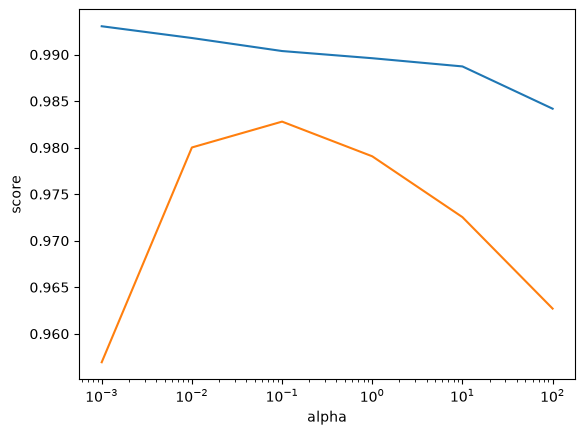

In [33]:
plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('score')

plt.show()